In [1]:
import numpy as np
import sys
path = '/home/momichael98/temp/Fortran/DiagE/class'
sys.path.append(path)
from ClassDiagE_new import Crystal as cr
from ClassDiagE_new import FHamiltonian as fh
from ClassDiagE_new import BHamiltonian as bh
from ClassDiagE_new import FT_grid as ft
from ClassDiagE_new import Method
path = '/home/momichael98/temp/Fortran/DiagE/modules'
sys.path.append(path)
import DiagE

## Generate Crystal & Basic system

In [2]:
latt = [[1.0,0.0,0.0],[1/2,np.sqrt(3)/2,0.0],[0.0,0.0,10.0]]
pos = [[1/3,1/3,1/2],[2/3,2/3,1/2]]

Graphene = cr(latt,pos)
grid = [15,15,1]
Graphene.Kpoint(meshgrid=grid)

In [3]:
Gf = fh(Graphene,1)
Gb = bh(Graphene,1)

orb_option1 = [0,1]
orb_option2 = [1,1]

Gf.set_basis_index(orb_option1)
Gf.set_basis_index(orb_option2)

Gb.set_basis_index(orb_option1)
Gb.set_basis_index(orb_option2)

## Construct Non-interacting Hamiltonian

In [4]:
t = -2.7
e = 0.0
Gf.On_site_list(e)
Gf.On_site_list(e)

Gf.Hoppinglist(t,0,1,0,0,0)
Gf.Hoppinglist(t,1,0,1,0,0)
Gf.Hoppinglist(t,1,0,0,1,0)

Ham_tb = Gf.Hamiltonian(Gf.kpoint)

### Visualization of tight_binding Hamiltonian

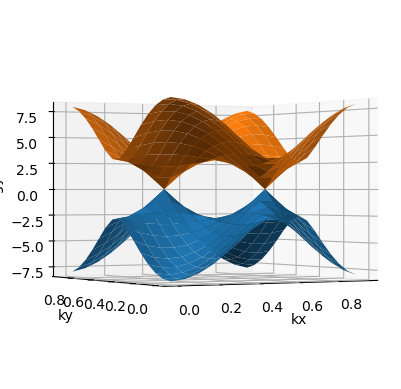

In [5]:
energy = Gf.diagonalization(Ham_tb)
Gf.visualization(energy,'./png/Graphene_tb')

## Construct the interacting Hamiltonian

In [6]:
U = 5
option1 = {"KorS" : "S", "value" : [U,0,0], "site" : 0, "orbital" : [0]}
option2 = {"KorS" : "S", "value" : [U,0,0], "site" : 0, "orbital" : [1]}

Gb.local_interacting(option1)
Gb.local_interacting(option2)

V = 2

Gb.set_int_amp(V,1,0,[1,0,0])
Gb.set_int_amp(V,1,0,[0,1,0])
Gb.set_int_amp(V,0,1,[0,0,0])

Gb.gen_nl_int_ham(grid)
Gb.Combine_interaction()

0 [0]
0 [0]


/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:744: ComplexWarning: Casting complex values to real discards the imaginary part
  V = np.array(tempmat,dtype=float,order='F')


In [7]:
Gb.V_bare[:,:,0,0,0]

array([[10.+0.j,  3.+0.j],
       [ 3.+0.j, 10.+0.j]])

## Hartree-Fock approximation

### Construct FT grid & Method class

In [8]:
beta = 38.0
size = 1000
FT = ft(beta,size)

FT.Omega()
FT.Tau()
FT.Nu()

GM = Method(Gb)
GM.mapping_full_sub()
GM.mapping_mR_R(grid)

(2.34403056330601e-05+0j)
(0.0002109624036762403+0j)
(0.0005860047489963938+0j)
(0.001148563640073763+0j)
(0.0018986335246835573+0j)
(0.0028362069999360306+0j)
(0.0039612748123587505+0j)
(0.0052738258579894115+0j)
(0.0067738471824770885+0j)
(0.008461323981219349+0j)
(0.010336239599497254+0j)
(0.012398575532652556+0j)
(0.014648311426264882+0j)
(0.017085425076345806+0j)
(0.019709892429566667+0j)
(0.02252168758349904+0j)
(0.02552078278685521+0j)
(0.028707148439779284+0j)
(0.03208075309412772+0j)
(0.035641563453783665+0j)
(0.039389544374985985+0j)
(0.043324658866679466+0j)
(0.047446868090869176+0j)
(0.051756131363014934+0j)
(0.05625240615242999+0j)
(0.06093564808269447+0j)
(0.06580581093210258+0j)
(0.07086284663411613+0j)
(0.0761067052778307+0j)
(0.08153733510847772+0j)
(0.0871546825279349+0j)
(0.09295869209525365+0j)
(0.09894930652719691+0j)
(0.10512646669882353+0j)
(0.11149011164405354+0j)
(0.11804017855628413+0j)
(0.12477660278899505+0j)
(0.13169931785640043+0j)
(0.13880825543409847+0j)

### SCF loop of Hartree-Fock

In [9]:
iter = 100
mu = 10
Nt = 1
H_hf = GM.SCF_Hartree_Fock(iter,Ham_tb,FT.tau,mu,Nt,GM.V_bare,grid)

/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:2092: ComplexWarning: Casting complex values to real discards the imaginary part
  gf = DiagE.bare.flattau(Ham_0,tau)


/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:1630: ComplexWarning: Casting complex values to real discards the imaginary part
  nmat[iorb,iorb,js] += -flattau[iorb,iorb,js,ik,ntau-1]
/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:1708: ComplexWarning: Casting complex values to real discards the imaginary part
  Gf_temp[jorb2,jorb1,0] += Gnot[jorb2,jorb1,0,jk,ntau-1]
/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  Energy[iorb1,iorb2,0,ik] += -Vinput[iorb,jorb,0,0,0]*1/nk*Gf_temp[jorb2,jorb1,0]*C
/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:1745: ComplexWarning: Casting complex values to real discards the imaginary part
  Energy[iorb1,jorb1,s1,:] = Gf[iorb2,jorb2,s1,:] * Vinput[iorb,jorb,s1,s1,:]
/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:1547: ComplexWarning: Casting complex values to real discards the imaginary part
  gf = DiagE

[[0.5 0. ]
 [0.  0.5]] [[0.4999502 0.       ]
 [0.        0.4999502]] 1
Converge complete 1 8.171004750532802


/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:2112: ComplexWarning: Casting complex values to real discards the imaginary part
  Gf_hf = DiagE.bare.flattau(Ham_hf,tau)


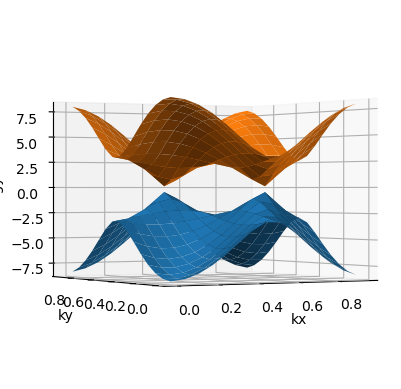

In [10]:
energy_hf = Gf.diagonalization(H_hf)
Gf.visualization(energy_hf,'./png/Graphene_HF')

In [11]:
energy_hf[:,:,1].min()

0.11597043547769398

## GW approximation

In [12]:
G_full, Hartree, Fock, Sigma_C, Chem = GM.SCF(100,Ham_tb,GM.V_bare,grid,FT,0,Nt)

/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:2145: ComplexWarning: Casting complex values to real discards the imaginary part
  G_not_kt = DiagE.bare.flattau(Hmat,tau)


1


/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:1442: ComplexWarning: Casting complex values to real discards the imaginary part
  bf = DiagE.fourier.blocdyn_t2f(tau,btau,freq)
/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:1404: ComplexWarning: Casting complex values to real discards the imaginary part
  momentum, high = DiagE.fourier.blocdyn_m(nu,ff,oddzero,highzero)
/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:1481: ComplexWarning: Casting complex values to real discards the imaginary part
  ftau = DiagE.fourier.blocdyn_f2t(nu,fnu,momentum,tau)
/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:1424: ComplexWarning: Casting complex values to real discards the imaginary part
  ff = DiagE.fourier.flocdyn_t2f(tau,ftau,freq)
/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE_new.py:1382: ComplexWarning: Casting complex values to real discards the imaginary part
  momentum, high = DiagE.fourier.flocdyn_m(omega,ff,isgreen,highzero)
/

old [[[0.4999502]
  [0.       ]]

 [[0.       ]
  [0.4999502]]] 
 new [[[0.49911598]
  [0.        ]]

 [[0.        ]
  [0.5009206 ]]] 
 diff [[[0.00083422]
  [0.        ]]

 [[0.        ]
  [0.0009704 ]]]
Converge complete 1 7.998690734731326


In [13]:
Sigma_stc = GM.Stc_Correlated_self_energy(Sigma_C)

In [14]:
Sigma_stc.shape

(2, 2, 1, 225)

In [15]:
Z = GM.z_factor(Sigma_C,beta)

In [16]:
Z.shape

(2, 2, 1, 225)

In [17]:
H_qp = GM.QP_Hamiltonian(Ham_tb,Hartree,Fock,Sigma_stc,Chem[:,:,:,:,0],Z)

In [18]:
energy_QP = Gf.diagonalization(H_qp)

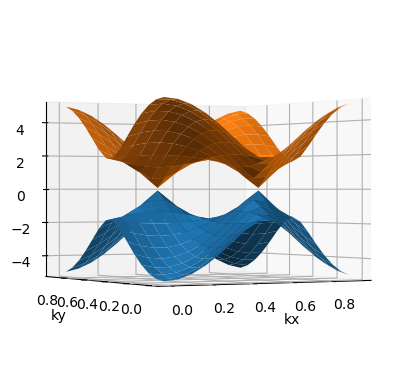

In [19]:
Gf.visualization(energy_QP,'./png/Graphene_GW')

In [20]:
norb = Z.shape[0]
ns = Z.shape[2]
nk = Z.shape[3]
eig_val = np.zeros((norb,ns,nk),dtype=complex)
for ik in range(nk):
    for js in range(ns):
        eig_val[:,js,ik] = np.linalg.eigvalsh(Z[:,:,js,ik])

/home/momichael98/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


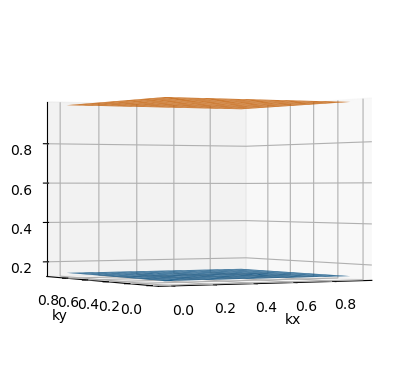

In [21]:
Gf.visualization(eig_val.T,'temp')

In [22]:
eig_val[:,0,0].min()

(0.14365734902302618+0j)